# Social Media Analytics

Author: Gia Phat Le

Github: https://github.com/PhatLene


## Library Import

In [4]:
import requests
import pandas as pd
import re
import pprint
import matplotlib.pyplot as plt
import seaborn as sns


## Helper Functions

In [5]:
def iso_to_time(duration):
    h, m, s = re.match(
        r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?',
        duration
    ).groups()
    h, m, s = int(h or 0), int(m or 0), int(s or 0)
    return f"{h}:{m:02}:{s:02}" if h else f"{m}:{s:02}"

def get_qid(claims, prop):
    return claims[prop][0]["mainsnak"]["datavalue"]["value"]["id"] if prop in claims else None

## Wikipedia

In [6]:
## Wikipedia API endpoint
url = "https://en.wikipedia.org/w/api.php"

In [7]:
## Code for accessing Wikipedia data using Wikidata API

dictL = []
pl = ['Lando Norris','Stephen Curry', 'Cristiano Ronaldo', 'Charles Leclerc', 'Giannis Antetokounmpo', 'LaMelo Ball','Taylor Swift', 'Billie Eilish', 'Logan Paul', 'MrBeast']
for person in pl:
    url = "https://www.wikidata.org/w/api.php"
    params = {
        "action": "wbgetentities",
        "sites": "enwiki",
        "titles": person,
        "props": "claims",
        "format": "json"
    }
    headers = {"User-Agent": "MyWikiApp/1.0 ldcomia@myseneca.ca"}
    response = requests.get(url, params=params, headers=headers)
    data = response.json()

    entity_id = list(data["entities"].keys())[0]
    claims = data["entities"][entity_id]["claims"]

    dob = claims["P569"][0]["mainsnak"]["datavalue"]["value"]["time"]
    pob = claims["P19"][0]["mainsnak"]["datavalue"]["value"]["id"]
    gender = claims["P21"][0]["mainsnak"]["datavalue"]["value"]["id"]
    citizenship = claims["P27"][0]["mainsnak"]["datavalue"]["value"]["id"]

    ## Retrieved data is in code form, the following code is used to retrieve their value using another API call
    qid_map = {
        "place_of_birth": pob,
        "gender": gender,
        "citizenship": citizenship
    }

    ids = "|".join([pob, gender, citizenship])
    params = {
        "action": "wbgetentities",
        "ids": ids,
        "props": "labels",
        "languages": "en",
        "format": "json"
    }
    response = requests.get(url, params=params, headers=headers)
    data = response.json()

    labels_dict = {}
    for prop, qid in qid_map.items():
        entity = data["entities"].get(qid)
        if entity and "labels" in entity and "en" in entity["labels"]:
            labels_dict[prop] = entity["labels"]["en"]["value"]
        else:
            labels_dict[prop] = None
    labels_dict['date_of_birth'] = dob.strip("+").split("T")[0]


    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "prop": "extracts",
        "exintro": True,
        "explaintext": True,
        "titles": person,
        "format": "json"
    }
    response = requests.get(url, params=params, headers=headers)
    data = response.json()
    page = next(iter(data["query"]["pages"].values()))
    intro = page.get("extract", "")
    first_sentence = intro.split(". ")[0] + "." if intro else ""
    labels_dict['Person'] = person
    labels_dict['Wikipeda_FirstSentence'] = first_sentence


    dictL.append(labels_dict)


In [8]:
## Wikipedia Data Dataframe
df = pd.DataFrame(dictL)
pl = df['Person'].to_list()
df

,place_of_birth,gender,citizenship,date_of_birth,Person,Wikipeda_FirstSentence
0,Bristol,male,United Kingdom,1999-11-13,Lando Norris,Lando Norris ( ; born 13 November 1999) is a ...
1,Akron,male,United States,1988-03-14,Stephen Curry,Wardell Stephen Curry II ( STEF-ən; born March...
2,Funchal,male,Portugal,1985-02-05,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro (born 5 Fe...
3,Monte Carlo,male,Monaco,1997-10-16,Charles Leclerc,Charles Marc Hervé Perceval Leclerc (French pr...
4,Athens,male,Greece,1994-12-06,Giannis Antetokounmpo,Giannis Sina Ougko Antetokounmpo (born Giannis...
5,Chino Hills,male,United States,2001-08-22,LaMelo Ball,"LaMelo LaFrance Ball ( lə-MEL-oh; August 22, 2..."
6,West Reading,female,United States,1989-12-13,Taylor Swift,"Taylor Alison Swift (born December 13, 1989) i..."
7,Los Angeles,female,United States,2001-12-18,Billie Eilish,Billie Eilish Pirate Baird O'Connell ( EYE-lis...
8,Westlake,male,United States,1995-04-01,Logan Paul,"Logan Alexander Paul (born April 1, 1995) is a..."
9,Wichita,male,United States,1998-05-07,MrBeast,"James Stephen ""Jimmy"" Donaldson (born May 7, 1..."


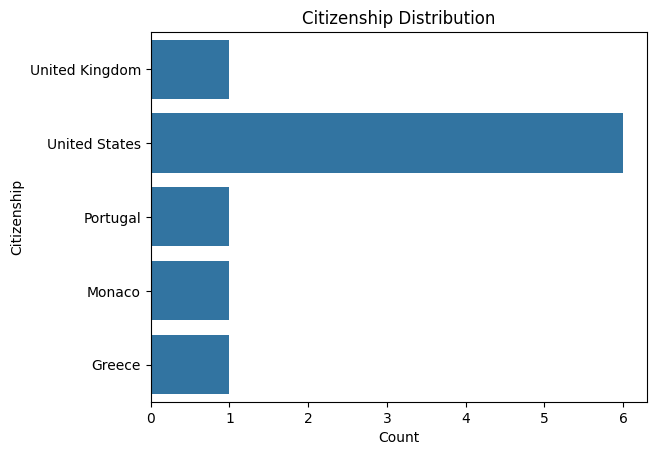

In [9]:
## Wikipedia Data Plot
sns.countplot(data=df, y='citizenship')
plt.title('Citizenship Distribution')
plt.xlabel('Count')
plt.ylabel('Citizenship')
plt.show()

## Youtube

In [ ]:
## Youtube API Key and Endpoints
API_KEY = "Enter your own API key"
channel_url = "https://www.googleapis.com/youtube/v3/channels"
playlist_url = "https://www.googleapis.com/youtube/v3/playlistItems"
videos_url = "https://www.googleapis.com/youtube/v3/videos"

### Obtaining Channel Information

In [11]:
## Selected Personalities Channel ID
channel_ids = ['UCwFIQ7wtJzYGFb2nZcVoNww','UC_PXxlBAEnFUXy2Z240jcrQ', 'UCtxD0x6AuNNqdXO9Wp5GHew', 'UCIzIX1qgW7P3eF6JCk_afCA','UCrMiMJMUSjELs0jb1vtTiAg',
               'UCbp_aYD6LNSMQTNYfa5OrwQ','UCqECaJ8Gagnn7YCbPEzWH6g','UCDGmojLIoWpXok597xYo8cg','UCbwMZHCMpBiOWfYLBOH-9Qw','UCX6OQ3DkcsbYNE6H8uQQuVA',]

In [12]:
## Loop for obtaining channel information including subscriber count, view count, and more
ch_list = []
for ids in channel_ids:
    channel_params = {
    "part": "snippet,statistics,contentDetails,status", ## Determines which data is included
    "id": ids,
    "key": API_KEY}

    channel_data = requests.get(channel_url, params=channel_params).json()

    # Add a check to ensure 'items' key exists and is not empty
    if 'items' not in channel_data or not channel_data['items']:
        print(f"No channel data found for ID: {ids}. Skipping.")
        continue

    ch_description = channel_data['items'][0]['snippet']['description']
    ch_sub_count = channel_data['items'][0]['statistics']['subscriberCount']
    ch_total_vids = channel_data['items'][0]['statistics']['videoCount']
    ch_total_views = channel_data['items'][0]['statistics']['viewCount']
    ch_country = channel_data['items'][0]['snippet'].get('country', 'Unknown') ## Some channels do not provide a country, will be replaced with 'unkown'
    ch_title = channel_data['items'][0]['snippet']['title']
    ch_dict  = {'YT_ChannelTitle': ch_title,
               'YT_SubscriberCount': ch_sub_count,
               'YT_TotalViews': ch_total_views,
               'YT_TotalVideos': ch_total_vids,
               'YT_Country':ch_country,
               'YT_ChannelDescription': ch_description}
    ch_list.append(ch_dict)

In [13]:
## Dataframe for Youtube Data
df2 = pd.DataFrame(ch_list)
df2['Person'] = pl
df2.head(10)

,YT_ChannelTitle,YT_SubscriberCount,YT_TotalViews,YT_TotalVideos,YT_Country,YT_ChannelDescription,Person
0,Lando Norris,1400000,36600306,37,GB,McLaren Formula 1 Racing Driver,Lando Norris
1,Stephen Curry,2090000,101602900,216,US,This is the official channel for Golden State ...,Stephen Curry
2,UR · Cristiano,78500000,973887730,131,PT,Welcome to UR Cristiano - the official YouTube...,Cristiano Ronaldo
3,Charles Leclerc,1510000,57598062,75,FR,The official YouTube channel for Ferrari Formu...,Charles Leclerc
4,Giannis Antetokounmpo,318000,34103013,70,US,I want to give you a look behind-the-scenes at...,Giannis Antetokounmpo
5,LaMelo Ball,47100,0,0,US,The official YouTube of LaMelo Ball aka Dip. F...,LaMelo Ball
6,Taylor Swift,63100000,44367394830,658,Unknown,"And, baby, that’s show business for you. New a...",Taylor Swift
7,BillieEilishVEVO,1160000,14153749803,183,Unknown,,Billie Eilish
8,TheOfficialLoganPaul,6120000,1596291551,544,US,"Creator, artist, entrepreneur, business lad.",Logan Paul
9,MrBeast,474000000,116345617363,959,US,SUBSCRIBE FOR A COOKIE!\nNew MrBeast or MrBeas...,MrBeast


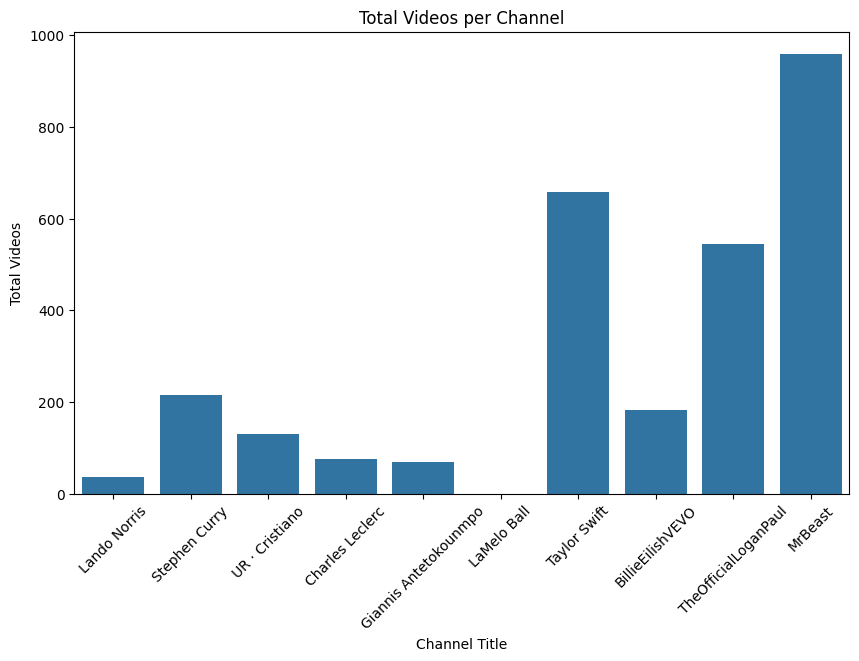

In [14]:
## Plot of Youtube Data
df2['YT_TotalVideos'] = df2['YT_TotalVideos'].astype(int)
plt.figure(figsize=(10, 6))
sns.barplot(data=df2, x='YT_ChannelTitle', y='YT_TotalVideos')
plt.xticks(rotation=45)
plt.xlabel('Channel Title')
plt.ylabel('Total Videos')
plt.title('Total Videos per Channel')
plt.show()


## Twitter

In [ ]:
## Twitter API Bearer Token
bearer_token="Enter your own API key"

In [16]:
## Twitter Usernames of Personalities
users = ['StephenCurry30', 'LandoNorris', 'Cristiano','Charles_Leclerc','Giannis_An34', 'MrBeast', 'billieeilish', 'taylorswift13', 'LoganPaul', 'MELOD1P']

## Code used to obtain Twitter Data
twitterAccs = []
for user in users:
    headers = {"Authorization": f"Bearer {bearer_token}"}
    url = f"https://api.twitter.com/2/users/by/username/{user}"
    params = {"user.fields": "public_metrics"}
    response = requests.get(url, headers=headers, params=params)

    data = response.json()['data']
    acc_id = data['id']

    url_tweets = f"https://api.twitter.com/2/users/{acc_id}/tweets"
    params_tweets = {
        "max_results": 5,
        "tweet.fields": "created_at,public_metrics,text"
    }
    response_tweets = requests.get(url_tweets, headers=headers, params=params_tweets)
    tweets_data = response_tweets.json()
    latest = tweets_data['data'][0]

    twitter_info = {
    "TwitterName": data['name'],
    "TwitterFollowers": data['public_metrics']['followers_count'],
    "NumberOfTweets": data['public_metrics']['tweet_count'],
    "TwitterFollowing": data['public_metrics']['following_count'],
    "TwitterUsername": data['username'], "LatestTweet": latest['text'],
    "LatestTweetTime": latest['created_at'],
    "LatestTweetLikes": latest['public_metrics']['like_count']}

    twitterAccs.append(twitter_info)

In [17]:
## Dataframe of Twitter Data
pl2 = ['Stephen Curry', 'Lando Norris','Cristiano Ronaldo', 'Charles Leclerc', 'Giannis Antetokounmpo', 'MrBeast','Billie Eilish', 'Taylor Swift', 'Logan Paul', 'LaMelo Ball']
df3 = pd.DataFrame(twitterAccs)
df3['Person'] = pl2
df3

,TwitterName,TwitterFollowers,NumberOfTweets,TwitterFollowing,TwitterUsername,LatestTweet,LatestTweetTime,LatestTweetLikes,Person
0,Stephen Curry,17518708,8296,846,StephenCurry30,Taking the Underrated Golf Tour global has alw...,2026-03-24T17:00:58.000Z,1101,Stephen Curry
1,Lando Norris,2894411,7063,69,LandoNorris,😈😈😈😈😈 https://t.co/U8CTyQSuwU,2024-07-05T09:48:08.000Z,40957,Lando Norris
2,Cristiano Ronaldo,106527878,4437,80,Cristiano,Getting ready 💪🏽 https://t.co/QPy2o0yllp,2026-04-02T20:09:58.000Z,152144,Cristiano Ronaldo
3,Charles Leclerc,3767396,2402,188,Charles_Leclerc,back home 🩵 @vistajet https://t.co/vo2zWOsu9r,2026-04-01T18:23:39.000Z,15549,Charles Leclerc
4,Giannis Antetokounmpo,3370088,51,9,Giannis_An34,I’m excited about this one. I’m officially a p...,2026-04-02T14:18:36.000Z,311,Giannis Antetokounmpo
5,MrBeast,34414278,7840,2290,MrBeast,@johncoogan @sama Call me!,2026-04-02T18:25:07.000Z,980,MrBeast
6,billie eilish,8082357,1293,0,billieeilish,HIT ME HARD AND SOFT: THE TOUR (LIVE IN 3D) in...,2026-03-17T17:06:55.000Z,21649,Billie Eilish
7,Taylor Swift,79408514,883,0,taylorswift13,I never want to forget a single detail of this...,2026-02-13T05:11:22.000Z,104107,Taylor Swift
8,Logan Paul,6404789,11482,4120,LoganPaul,First day as World Tag Team Champs ✅ https://t...,2026-03-31T23:11:03.000Z,13701,Logan Paul
9,Melo,1050041,2549,55,MELOD1P,play dat first full vid lmaooo kris💀💀💀💀love ga...,2026-03-27T04:23:26.000Z,34495,LaMelo Ball


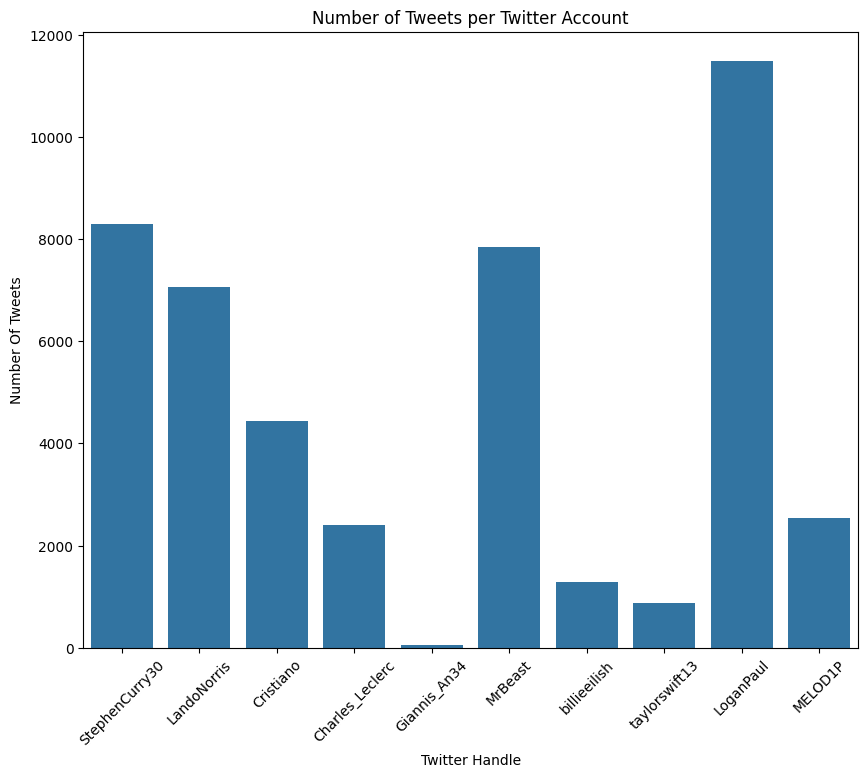

In [18]:
## Plot of Twitter Data
plt.figure(figsize=(10, 8))
sns.barplot(data=df3, x='TwitterUsername', y='NumberOfTweets')
plt.title('Number of Tweets per Twitter Account')
plt.xticks(rotation=45)
plt.xlabel('Twitter Handle')
plt.ylabel('Number Of Tweets')
plt.show()

## Instagram

In [19]:
!pip -q install apify-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.0/87.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 71.4 MB/s eta 0:00:00


In [ ]:
## Installing APIfy for Instagram Access
import os
APIFY_TOKEN = os.getenv("APIFY_TOKEN")
APIFY_TOKEN = "Enter your own API key"

if not APIFY_TOKEN:
    raise ValueError("Missing APIFY_TOKEN. Add it as an environment variable or set it in the notebook.")

In [21]:
## Code used to obtain Instagram Data
from apify_client import ApifyClient
import pandas as pd

client = ApifyClient(APIFY_TOKEN)
ig_usernames = [
    'lando',
    'stephencurry30',
    'cristiano',
    'charles_leclerc',
    'giannis_an34',
    "melo",
    "taylorswift",
    "billieeilish",
    "loganpaul",
    "mrbeast",

]

ig_run_input = {
    "usernames": ig_usernames,
    "includeAboutSection": False,  # paid-only per actor docs, so keep False
}

ig_run = client.actor("apify/instagram-profile-scraper").call(run_input=ig_run_input)
ig_items = list(client.dataset(ig_run["defaultDatasetId"]).iterate_items())

# Normalize into a clean dataframe (use .get because actor fields can vary)
ig_rows = []
for it in ig_items:
    ig_rows.append({
        "InstagramUsername": it.get("username") or it.get("userName"),
        "InstagramBio": it.get("biography") or it.get("bio"),
        "InstagramFollowers": it.get("followersCount") or it.get("followers"),
        "InstagramFollowing": it.get("followsCount") or it.get("following"),
        "InstagramPosts": it.get("postsCount") or it.get("posts"),
        "InstagramVerified": it.get("verified"),
        "IG_LatestPostTimestamp": (it.get("latestPosts", [{}])[0].get("timestamp") if isinstance(it.get("latestPosts"), list) and it.get("latestPosts") else None),
        "IG_LatestPostLikes": (it.get("latestPosts", [{}])[0].get("likesCount") if isinstance(it.get("latestPosts"), list) and it.get("latestPosts") else None),
        "IG_LatestPostComments": (it.get("latestPosts", [{}])[0].get("commentsCount") if isinstance(it.get("latestPosts"), list) and it.get("latestPosts") else None),
    })

[apify.instagram-profile-scraper runId:mEpSLlz42eVRF82uj] -> Status: RUNNING, Message: 
[apify.instagram-profile-scraper runId:mEpSLlz42eVRF82uj] -> 2026-04-03T02:44:52.449Z ACTOR: Pulling container image of build M8EJWRn6NRgEDwiSb from registry.
[apify.instagram-profile-scraper runId:mEpSLlz42eVRF82uj] -> 2026-04-03T02:44:52.451Z ACTOR: Creating container.
[apify.instagram-profile-scraper runId:mEpSLlz42eVRF82uj] -> 2026-04-03T02:44:52.515Z ACTOR: Starting container.
[apify.instagram-profile-scraper runId:mEpSLlz42eVRF82uj] -> 2026-04-03T02:44:52.519Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.instagram-profile-scraper runId:mEpSLlz42eVRF82uj] -> 2026-04-03T02:44:53.893Z INFO  System info {"apifyVersion":"3.6.0","apifyClientVersion":"2.22.2","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v22.22.1"}
[apify.instagram-profile-scraper runId:mEpSLlz42eVRF82uj] -> 2026-04-03T02:44:54.072Z INFO  Results Limit [object Object], ACTOR_MAX_PAID_DATASET_ITEMS
[

In [22]:
## Instagram data Dataframe
ig_df = pd.DataFrame(ig_rows)
name_map = {
    "mrbeast": "MrBeast",
    "cristiano": "Cristiano Ronaldo",
    "melo": "LaMelo Ball",
    "loganpaul": "Logan Paul",
    "billieeilish": "Billie Eilish",
    "giannis_an34": "Giannis Antetokounmpo",
    "stephencurry30": "Stephen Curry",
    "taylorswift": "Taylor Swift",
    "lando": "Lando Norris",
    "charles_leclerc": "Charles Leclerc"
}

ig_df["Person"] = ig_df["InstagramUsername"].map(name_map)
ig_df

,InstagramUsername,InstagramBio,InstagramFollowers,InstagramFollowing,InstagramPosts,InstagramVerified,IG_LatestPostTimestamp,IG_LatestPostLikes,IG_LatestPostComments,Person
0,stephencurry30,Believer. Husband. Father. Founder. Philanthro...,58258801,1262.0,1530,True,2026-03-31T16:12:09.000Z,100986,483,Stephen Curry
1,billieeilish,“HIT ME HARD AND SOFT” THE ALBUM\nOUT NOW,125290433,NaN,1040,True,2024-04-08T15:00:07.000Z,10310391,226773,Billie Eilish
2,loganpaul,artist — collector — wrestler\nfounder @drinkp...,26806395,1030.0,1363,True,2026-01-13T17:32:53.000Z,674451,9299,Logan Paul
3,cristiano,None,672883042,630.0,4033,True,2026-04-02T20:05:16.000Z,2064900,17050,Cristiano Ronaldo
4,lando,F1 World Champion,11793782,715.0,1948,True,2026-04-01T15:42:58.000Z,449786,1807,Lando Norris
5,mrbeast,Beast Games 2 Strong Vs Smart is out!!,85805140,925.0,470,True,2024-11-28T20:10:49.000Z,19746075,191615,MrBeast
6,taylorswift,"And, baby, that’s show business for you. New a...",280380921,NaN,704,True,2026-02-06T13:02:00.000Z,4516147,0,Taylor Swift
7,giannis_an34,None,16004399,253.0,17,True,2026-04-02T14:15:10.000Z,16316,186,Giannis Antetokounmpo
8,charles_leclerc,Formula 1 driver @scuderiaferrari,23645574,1383.0,1483,True,2026-03-02T16:51:29.000Z,10655023,35276,Charles Leclerc
9,melo,1 of 1 🕺🏽🛸💕,10699768,160.0,563,True,2026-04-02T15:45:36.000Z,21658,119,LaMelo Ball


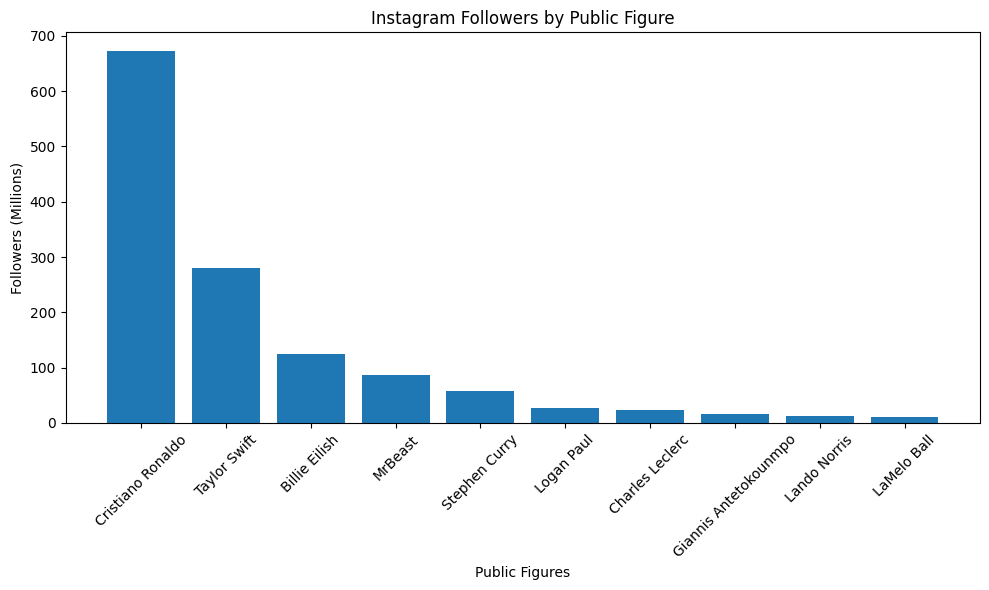

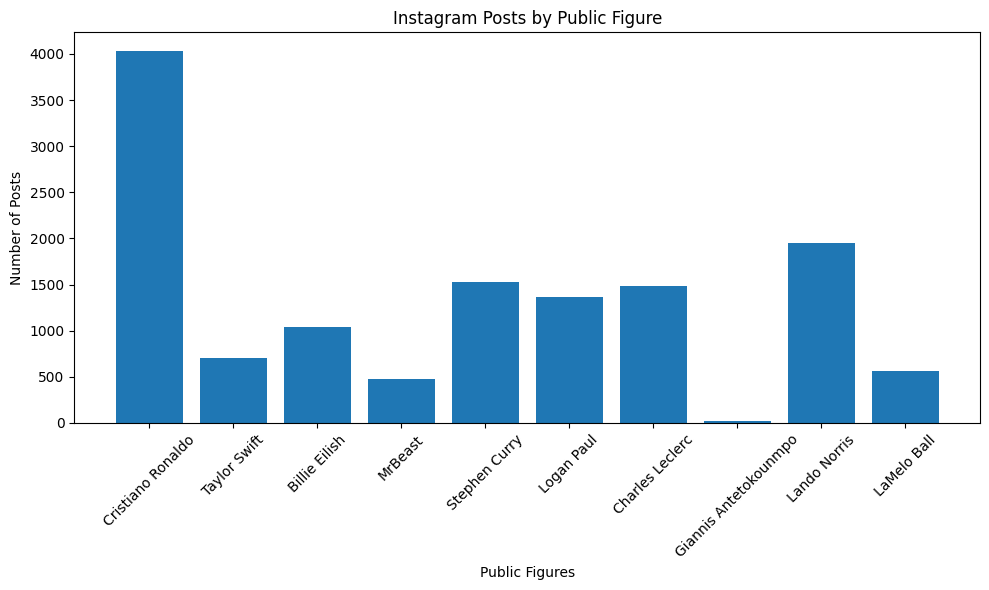

In [23]:
## Instagram Data Plots

ig_df = ig_df.sort_values(by="InstagramFollowers", ascending=False)

# Instagram Followers Bar Plot

plt.figure(figsize=(10,6))

plt.bar(
    ig_df["Person"],
    ig_df["InstagramFollowers"] / 1_000_000
)

plt.title("Instagram Followers by Public Figure")
plt.xlabel("Public Figures")
plt.ylabel("Followers (Millions)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Instagram Posts Bar Plot
plt.figure(figsize=(10,6))

plt.bar(
    ig_df["Person"],
    ig_df["InstagramPosts"]
)

plt.title("Instagram Posts by Public Figure")
plt.xlabel("Public Figures")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##Tiktok


In [24]:
client = ApifyClient(APIFY_TOKEN)
tiktok_usernames = [
    "lamelowithball2",
    "taylorswift",
    "billieeilish",
    "loganpaul",
    "mrbeast",
    'landonorris',


]

tt_run_input = {
    "profiles": tiktok_usernames,     # actor accepts usernames/user IDs
    "resultsPerPage": 5,              # scrape up to 5 recent videos per profile
    "profileScrapeSections": ["videos"],
    "profileSorting": "latest",
    "excludePinnedPosts": False,
}

tt_run = client.actor("clockworks/tiktok-scraper").call(run_input=tt_run_input)
tt_items = list(client.dataset(tt_run["defaultDatasetId"]).iterate_items())

tt_rows = []
for it in tt_items:
    author = it.get("authorMeta") or {}
    stats = it.get("authorStats") or {}
    video_stats = it.get("stats") or {}

    tt_rows.append({
        "Platform": "TikTok",
        "TikTokUsername": author.get("name") or author.get("nickName") or it.get("authorUniqueId"),
        "TikTokDisplayName": author.get("nickName"),
        "TikTokFollowers": stats.get("followerCount"),
        "TikTokFollowing": stats.get("followingCount"),
        "TikTokHearts": stats.get("heartCount"),
        "TikTokVideos": stats.get("videoCount"),
        "TT_LatestVideoTime": it.get("createTimeISO") or it.get("createTime"),
        "TT_LatestVideoLikes": video_stats.get("diggCount"),
        "TT_LatestVideoComments": video_stats.get("commentCount"),
        "TT_LatestVideoShares": video_stats.get("shareCount"),
        "TT_LatestVideoPlays": video_stats.get("playCount"),
        "TT_LatestVideoUrl": it.get("webVideoUrl") or it.get("videoUrl"),
    })

tt_df_raw = pd.DataFrame(tt_rows)
tt_df = (
    tt_df_raw
    .sort_values(by=["TikTokUsername", "TT_LatestVideoTime"], ascending=[True, False])
    .drop_duplicates(subset=["TikTokUsername"], keep="first")
    .reset_index(drop=True)
)

tt_df

[apify.tiktok-scraper runId:O7BLMxxjouUTzC6ZK] -> Status: RUNNING, Message: 
[apify.tiktok-scraper runId:O7BLMxxjouUTzC6ZK] -> 2026-04-03T02:45:10.304Z ACTOR: Pulling container image of build hzCuJPLnJcagnd9O0 from registry.
[apify.tiktok-scraper runId:O7BLMxxjouUTzC6ZK] -> 2026-04-03T02:45:10.306Z ACTOR: Creating container.
[apify.tiktok-scraper runId:O7BLMxxjouUTzC6ZK] -> 2026-04-03T02:45:10.354Z ACTOR: Starting container.
[apify.tiktok-scraper runId:O7BLMxxjouUTzC6ZK] -> 2026-04-03T02:45:10.355Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.tiktok-scraper runId:O7BLMxxjouUTzC6ZK] -> 2026-04-03T02:45:10.662Z Running on architecture: x86_64
[apify.tiktok-scraper runId:O7BLMxxjouUTzC6ZK] -> 2026-04-03T02:45:10.664Z Will run command: xvfb-run -a -s "-ac -screen 0 1920x1080x24+32 -nolisten tcp" /bin/bash -o pipefail -c bash -c "    java         --enable-native-access=ALL-UNNAMED         -cp classes-test:classes-main:lib/*         com.zhiliaoapp.musically.MetaSec    

,Platform,TikTokUsername,TikTokDisplayName,TikTokFollowers,TikTokFollowing,TikTokHearts,TikTokVideos,TT_LatestVideoTime,TT_LatestVideoLikes,TT_LatestVideoComments,TT_LatestVideoShares,TT_LatestVideoPlays,TT_LatestVideoUrl
0,TikTok,billieeilish,BILLIE EILISH,None,None,None,None,2025-11-24T00:45:03.000Z,None,None,None,None,https://www.tiktok.com/@billieeilish/video/757...
1,TikTok,lamelowithball2,LaMelo Ball 🛸🔥,None,None,None,None,2024-05-11T04:55:45.000Z,None,None,None,None,https://www.tiktok.com/@lamelowithball2/video/...
2,TikTok,landonorris,Lando Norris,None,None,None,None,2026-03-25T12:53:55.000Z,None,None,None,None,https://www.tiktok.com/@landonorris/video/7621...
3,TikTok,loganpaul,Logan Paul,None,None,None,None,2026-04-01T15:27:35.000Z,None,None,None,None,https://www.tiktok.com/@loganpaul/video/762381...
4,TikTok,mrbeast,MrBeast,None,None,None,None,2026-03-29T16:21:06.000Z,None,None,None,None,https://www.tiktok.com/@mrbeast/video/76227133...
5,TikTok,taylorswift,Taylor Swift,None,None,None,None,2026-02-13T05:13:28.000Z,None,None,None,None,https://www.tiktok.com/@taylorswift/video/7606...


# Google Knowledge Graph Search

In [ ]:
## Google API Key and Endpoint
GOOGLE_API_KEY = "Enter your own API key"
KG_ENDPOINT = "https://kgsearch.googleapis.com/v1/entities:search"


def kg_search_person(query: str, api_key: str, limit: int = 1):
    params = {
        "query": query,
        "key": api_key,
        "limit": limit,
        "indent": True,
        "types": "Person",
        "languages": "en",
    }
    r = requests.get(KG_ENDPOINT, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    items = data.get("itemListElement", [])
    if not items:
        return None

    result = items[0].get("result", {})
    detailed = result.get("detailedDescription", {}) or {}
    image = result.get("image", {}) or {}

    return {
        "KG_Name": result.get("name"),
        "KG_Description": result.get("description"),
        "KG_Types": ", ".join(result.get("@type", [])) if isinstance(result.get("@type"), list) else result.get("@type"),
        "KG_DetailedSummary": detailed.get("articleBody"),
        "KG_DetailedURL": detailed.get("url"),
    }

pl3 = ['MrBeast','Cristiano Ronaldo', 'LaMelo Ball','Logan Paul','Billie Eilish', 'Giannis Antetokounmpo','Stephen Curry','Taylor Swift', 'Lando Norris','Charles Leclerc']

kg_rows = []
for name in pl3:
    row = kg_search_person(name, GOOGLE_API_KEY, limit=1)
    if row is None:
        kg_rows.append({"Platform": "GoogleKnowledgeGraph", "KG_Query": name, "KG_Found": False})
    else:
        kg_rows.append(row)

In [26]:
## Google Knowledge Graph API dataframe
kg_df = pd.DataFrame(kg_rows)
kg_df['Person'] = pl3
kg_df

,KG_Name,KG_Description,KG_Types,KG_DetailedSummary,KG_DetailedURL,Person
0,MrBeast,American YouTuber,"Thing, Person","James Stephen ""Jimmy"" Donaldson, better known ...",https://en.wikipedia.org/wiki/MrBeast,MrBeast
1,Cristiano Ronaldo,Portuguese footballer,"Thing, Person","Cristiano Ronaldo dos Santos Aveiro, nicknamed...",https://en.wikipedia.org/wiki/Cristiano_Ronaldo,Cristiano Ronaldo
2,LaMelo Ball,American basketball player,"Person, Thing",LaMelo LaFrance Ball is an American profession...,https://en.wikipedia.org/wiki/LaMelo_Ball,LaMelo Ball
3,Logan Paul,American Influencer and professional wrestler,"Person, Thing",Logan Alexander Paul is an American influencer...,https://en.wikipedia.org/wiki/Logan_Paul,Logan Paul
4,Billie Eilish,American singer-songwriter,"Thing, Person",Billie Eilish Pirate Baird O'Connell is an Ame...,https://en.wikipedia.org/wiki/Billie_Eilish,Billie Eilish
5,Giannis Antetokounmpo,Greek-Nigerian basketball player,"Thing, Person",Giannis Sina Ougko Antetokounmpo is a Greek an...,https://en.wikipedia.org/wiki/Giannis_Antetoko...,Giannis Antetokounmpo
6,Stephen Curry,American basketball point guard,"Thing, Person","Wardell Stephen Curry II, also known as Steph ...",https://en.wikipedia.org/wiki/Stephen_Curry,Stephen Curry
7,Taylor Swift,American singer-songwriter,"Thing, Person",Taylor Alison Swift is an American singer-song...,https://en.wikipedia.org/wiki/Taylor_Swift,Taylor Swift
8,Lando Norris,British-Belgian racing driver,"Person, Thing",Lando Norris is a British racing driver who co...,https://en.wikipedia.org/wiki/Lando_Norris,Lando Norris
9,Charles Leclerc,Monégasque motorsports racing driver,"Person, Thing",Charles Marc Hervé Perceval Leclerc is a Monég...,https://en.wikipedia.org/wiki/Charles_Leclerc,Charles Leclerc


##**Combined Dataframe**

In [27]:
## Merging all dataframes
merge1 = df.merge(df2,on='Person')
merge2 = merge1.merge(df3, on='Person')
merge3 = merge2.merge(kg_df, on='Person')
merge4 = merge3.merge(ig_df, on='Person')
merge4

,place_of_birth,gender,citizenship,date_of_birth,Person,Wikipeda_FirstSentence,YT_ChannelTitle,YT_SubscriberCount,YT_TotalViews,YT_TotalVideos,...,KG_DetailedURL,InstagramUsername,InstagramBio,InstagramFollowers,InstagramFollowing,InstagramPosts,InstagramVerified,IG_LatestPostTimestamp,IG_LatestPostLikes,IG_LatestPostComments
0,Bristol,male,United Kingdom,1999-11-13,Lando Norris,Lando Norris ( ; born 13 November 1999) is a ...,Lando Norris,1400000,36600306,37,...,https://en.wikipedia.org/wiki/Lando_Norris,lando,F1 World Champion,11793782,715.0,1948,True,2026-04-01T15:42:58.000Z,449786,1807
1,Akron,male,United States,1988-03-14,Stephen Curry,Wardell Stephen Curry II ( STEF-ən; born March...,Stephen Curry,2090000,101602900,216,...,https://en.wikipedia.org/wiki/Stephen_Curry,stephencurry30,Believer. Husband. Father. Founder. Philanthro...,58258801,1262.0,1530,True,2026-03-31T16:12:09.000Z,100986,483
2,Funchal,male,Portugal,1985-02-05,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro (born 5 Fe...,UR · Cristiano,78500000,973887730,131,...,https://en.wikipedia.org/wiki/Cristiano_Ronaldo,cristiano,None,672883042,630.0,4033,True,2026-04-02T20:05:16.000Z,2064900,17050
3,Monte Carlo,male,Monaco,1997-10-16,Charles Leclerc,Charles Marc Hervé Perceval Leclerc (French pr...,Charles Leclerc,1510000,57598062,75,...,https://en.wikipedia.org/wiki/Charles_Leclerc,charles_leclerc,Formula 1 driver @scuderiaferrari,23645574,1383.0,1483,True,2026-03-02T16:51:29.000Z,10655023,35276
4,Athens,male,Greece,1994-12-06,Giannis Antetokounmpo,Giannis Sina Ougko Antetokounmpo (born Giannis...,Giannis Antetokounmpo,318000,34103013,70,...,https://en.wikipedia.org/wiki/Giannis_Antetoko...,giannis_an34,None,16004399,253.0,17,True,2026-04-02T14:15:10.000Z,16316,186
5,Chino Hills,male,United States,2001-08-22,LaMelo Ball,"LaMelo LaFrance Ball ( lə-MEL-oh; August 22, 2...",LaMelo Ball,47100,0,0,...,https://en.wikipedia.org/wiki/LaMelo_Ball,melo,1 of 1 🕺🏽🛸💕,10699768,160.0,563,True,2026-04-02T15:45:36.000Z,21658,119
6,West Reading,female,United States,1989-12-13,Taylor Swift,"Taylor Alison Swift (born December 13, 1989) i...",Taylor Swift,63100000,44367394830,658,...,https://en.wikipedia.org/wiki/Taylor_Swift,taylorswift,"And, baby, that’s show business for you. New a...",280380921,NaN,704,True,2026-02-06T13:02:00.000Z,4516147,0
7,Los Angeles,female,United States,2001-12-18,Billie Eilish,Billie Eilish Pirate Baird O'Connell ( EYE-lis...,BillieEilishVEVO,1160000,14153749803,183,...,https://en.wikipedia.org/wiki/Billie_Eilish,billieeilish,“HIT ME HARD AND SOFT” THE ALBUM\nOUT NOW,125290433,NaN,1040,True,2024-04-08T15:00:07.000Z,10310391,226773
8,Westlake,male,United States,1995-04-01,Logan Paul,"Logan Alexander Paul (born April 1, 1995) is a...",TheOfficialLoganPaul,6120000,1596291551,544,...,https://en.wikipedia.org/wiki/Logan_Paul,loganpaul,artist — collector — wrestler\nfounder @drinkp...,26806395,1030.0,1363,True,2026-01-13T17:32:53.000Z,674451,9299
9,Wichita,male,United States,1998-05-07,MrBeast,"James Stephen ""Jimmy"" Donaldson (born May 7, 1...",MrBeast,474000000,116345617363,959,...,https://en.wikipedia.org/wiki/MrBeast,mrbeast,Beast Games 2 Strong Vs Smart is out!!,85805140,925.0,470,True,2024-11-28T20:10:49.000Z,19746075,191615


In [28]:
merge4.columns

Index(['place_of_birth', 'gender', 'citizenship', 'date_of_birth', 'Person',
       'Wikipeda_FirstSentence', 'YT_ChannelTitle', 'YT_SubscriberCount',
       'YT_TotalViews', 'YT_TotalVideos', 'YT_Country',
       'YT_ChannelDescription', 'TwitterName', 'TwitterFollowers',
       'NumberOfTweets', 'TwitterFollowing', 'TwitterUsername', 'LatestTweet',
       'LatestTweetTime', 'LatestTweetLikes', 'KG_Name', 'KG_Description',
       'KG_Types', 'KG_DetailedSummary', 'KG_DetailedURL', 'InstagramUsername',
       'InstagramBio', 'InstagramFollowers', 'InstagramFollowing',
       'InstagramPosts', 'InstagramVerified', 'IG_LatestPostTimestamp',
       'IG_LatestPostLikes', 'IG_LatestPostComments'],
      dtype='object')

## Upgrade: LLM-Powered Profile Summary

This lightweight upgrade uses the unified profile dataset as input and sends a structured prompt to an LLM to generate a short analytical summary, highlights, and risks/opportunities for each public figure. This keeps the existing API integration project intact while showing how the dataset can support an AI-powered application.


In [ ]:
import os
import json

os.environ["OPENAI_API_KEY"] = "Enter your own API key"

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_MODEL = "gpt-4o-mini"


In [38]:
import requests
import pandas as pd

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_MODEL = "gpt-4o-mini"


def safe_get(row, key, default=""):
    value = row.get(key, default)
    if pd.isna(value):
        return default
    return value


def build_profile_payload(row):
    return {
        "Person": safe_get(row, "Person"),
        "Citizenship": safe_get(row, "citizenship"),
        "DateOfBirth": safe_get(row, "date_of_birth"),

        "YouTubeChannel": safe_get(row, "YT_ChannelTitle"),
        "YouTubeSubscribers": safe_get(row, "YT_SubscriberCount"),
        "YouTubeTotalVideos": safe_get(row, "YT_TotalVideos"),
        "YouTubeTotalViews": safe_get(row, "YT_TotalViews"),

        "InstagramFollowers": safe_get(row, "InstagramFollowers"),
        "InstagramPosts": safe_get(row, "InstagramPosts"),
        "InstagramBio": safe_get(row, "InstagramBiography"),

        "KnowledgeGraphDescription": safe_get(row, "KG_Description"),
        "KnowledgeGraphSummary": safe_get(row, "KG_DetailedSummary"),

        "WikipediaSummary": safe_get(row, "Wiki_Summary"),
        "WikipediaURL": safe_get(row, "Wiki_URL")
    }


def summarize_profile_with_llm(row, api_key, model=OPENAI_MODEL):
    if not api_key:
        raise ValueError("Missing OPENAI_API_KEY. Set it as an environment variable before running this cell.")

    payload = build_profile_payload(row)

    system_prompt = (
        "You are an analyst turning multi-source profile data into concise business-style insights. "
        "Use only the supplied data. Do not invent facts. Keep the output structured, short, and practical."
    )

    user_prompt = f"""
Analyze this profile dataset and return valid JSON with exactly these keys:
summary, key_strengths, potential_risks, data_observations.

Rules:
- summary: 2 to 3 sentences
- key_strengths: list of 3 short strings
- potential_risks: list of up to 2 short strings
- data_observations: list of 3 short strings
- use only the provided data
- if some fields are missing, work with what is available

Profile data:
{json.dumps(payload, indent=2, default=str)}
"""

    response = requests.post(
        "https://api.openai.com/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json"
        },
        json={
            "model": model,
            "response_format": {"type": "json_object"},
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            "temperature": 0.3
        },
        timeout=60
    )

    response.raise_for_status()
    content = response.json()["choices"][0]["message"]["content"]
    return json.loads(content)

In [41]:
#Generate a demo LLM summary for one profile
example_row = merge4.iloc[0].to_dict()
llm_summary = summarize_profile_with_llm(example_row, OPENAI_API_KEY)
llm_summary

{'summary': 'Lando Norris is a prominent British racing driver known for his success in Formula One with McLaren. He has a substantial online presence, particularly on YouTube and Instagram, reflecting his popularity and engagement with fans.',
 'key_strengths': ['1.4 million YouTube subscribers',
  'Over 11.7 million Instagram followers',
  'Successful racing career with 11 Grand Prix wins'],
 'potential_risks': ['High public scrutiny due to fame',
  'Pressure to maintain performance in racing'],
 'data_observations': ['YouTube channel has 37 videos with over 36 million total views',
  'Instagram account has nearly 2,000 posts',
  "Lando Norris's racing achievements include winning the World Drivers' Championship in 2025"]}

In [44]:
results = []

for i in range(min(5, len(merge4))):
    row_dict = merge4.iloc[i].to_dict()
    llm_output = summarize_profile_with_llm(row_dict, OPENAI_API_KEY)

    results.append({
        "Person": row_dict.get("Person"),
        "summary": llm_output.get("summary"),
        "key_strengths": llm_output.get("key_strengths"),
        "potential_risks": llm_output.get("potential_risks"),
        "data_observations": llm_output.get("data_observations")
    })

llm_results_df = pd.DataFrame(results)
llm_results_df


,Person,summary,key_strengths,potential_risks,data_observations
0,Lando Norris,Lando Norris is a prominent British racing dri...,[Strong social media presence with over 11 mil...,"[High public scrutiny due to celebrity status,...",[YouTube channel has a total of 37 videos and ...
1,Stephen Curry,Stephen Curry is a prominent American basketba...,"[High social media engagement, Significant You...","[Dependence on social media for brand, Injury ...",[YouTube channel has over 2 million subscriber...
2,Cristiano Ronaldo,Cristiano Ronaldo is a renowned Portuguese foo...,"[Extensive social media presence, High engagem...","[Injury concerns due to age, Public scrutiny o...","[YouTube channel has 78.5 million subscribers,..."
3,Charles Leclerc,Charles Leclerc is a prominent Monégasque raci...,"[Strong social media following, Successful rac...","[High public scrutiny due to celebrity status,...",[YouTube channel has over 1.5 million subscrib...
4,Giannis Antetokounmpo,Giannis Antetokounmpo is a prominent Greek-Nig...,"[High social media engagement, Recognized as o...",[Injury risks associated with high-performance...,"[YouTube channel has 318,000 subscribers and 3..."


In [45]:
llm_results_df.to_csv("llm_profile_insights.csv", index=False)

In [29]:
## Exporting final csv
merge4.to_csv('DatasetOfUnifiedProfiles.csv')

In [30]:
## Final csv
df_final =pd.read_csv('/content/DatasetOfUnifiedProfiles.csv')
df_final.head(10)

,Unnamed: 0,place_of_birth,gender,citizenship,date_of_birth,Person,Wikipeda_FirstSentence,YT_ChannelTitle,YT_SubscriberCount,YT_TotalViews,...,KG_DetailedURL,InstagramUsername,InstagramBio,InstagramFollowers,InstagramFollowing,InstagramPosts,InstagramVerified,IG_LatestPostTimestamp,IG_LatestPostLikes,IG_LatestPostComments
0,0,Bristol,male,United Kingdom,1999-11-13,Lando Norris,Lando Norris ( ; born 13 November 1999) is a ...,Lando Norris,1400000,36600306,...,https://en.wikipedia.org/wiki/Lando_Norris,lando,F1 World Champion,11793782,715.0,1948,True,2026-04-01T15:42:58.000Z,449786,1807
1,1,Akron,male,United States,1988-03-14,Stephen Curry,Wardell Stephen Curry II ( STEF-ən; born March...,Stephen Curry,2090000,101602900,...,https://en.wikipedia.org/wiki/Stephen_Curry,stephencurry30,Believer. Husband. Father. Founder. Philanthro...,58258801,1262.0,1530,True,2026-03-31T16:12:09.000Z,100986,483
2,2,Funchal,male,Portugal,1985-02-05,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro (born 5 Fe...,UR · Cristiano,78500000,973887730,...,https://en.wikipedia.org/wiki/Cristiano_Ronaldo,cristiano,NaN,672883042,630.0,4033,True,2026-04-02T20:05:16.000Z,2064900,17050
3,3,Monte Carlo,male,Monaco,1997-10-16,Charles Leclerc,Charles Marc Hervé Perceval Leclerc (French pr...,Charles Leclerc,1510000,57598062,...,https://en.wikipedia.org/wiki/Charles_Leclerc,charles_leclerc,Formula 1 driver @scuderiaferrari,23645574,1383.0,1483,True,2026-03-02T16:51:29.000Z,10655023,35276
4,4,Athens,male,Greece,1994-12-06,Giannis Antetokounmpo,Giannis Sina Ougko Antetokounmpo (born Giannis...,Giannis Antetokounmpo,318000,34103013,...,https://en.wikipedia.org/wiki/Giannis_Antetoko...,giannis_an34,NaN,16004399,253.0,17,True,2026-04-02T14:15:10.000Z,16316,186
5,5,Chino Hills,male,United States,2001-08-22,LaMelo Ball,"LaMelo LaFrance Ball ( lə-MEL-oh; August 22, 2...",LaMelo Ball,47100,0,...,https://en.wikipedia.org/wiki/LaMelo_Ball,melo,1 of 1 🕺🏽🛸💕,10699768,160.0,563,True,2026-04-02T15:45:36.000Z,21658,119
6,6,West Reading,female,United States,1989-12-13,Taylor Swift,"Taylor Alison Swift (born December 13, 1989) i...",Taylor Swift,63100000,44367394830,...,https://en.wikipedia.org/wiki/Taylor_Swift,taylorswift,"And, baby, that’s show business for you. New a...",280380921,NaN,704,True,2026-02-06T13:02:00.000Z,4516147,0
7,7,Los Angeles,female,United States,2001-12-18,Billie Eilish,Billie Eilish Pirate Baird O'Connell ( EYE-lis...,BillieEilishVEVO,1160000,14153749803,...,https://en.wikipedia.org/wiki/Billie_Eilish,billieeilish,“HIT ME HARD AND SOFT” THE ALBUM\nOUT NOW,125290433,NaN,1040,True,2024-04-08T15:00:07.000Z,10310391,226773
8,8,Westlake,male,United States,1995-04-01,Logan Paul,"Logan Alexander Paul (born April 1, 1995) is a...",TheOfficialLoganPaul,6120000,1596291551,...,https://en.wikipedia.org/wiki/Logan_Paul,loganpaul,artist — collector — wrestler\nfounder @drinkp...,26806395,1030.0,1363,True,2026-01-13T17:32:53.000Z,674451,9299
9,9,Wichita,male,United States,1998-05-07,MrBeast,"James Stephen ""Jimmy"" Donaldson (born May 7, 1...",MrBeast,474000000,116345617363,...,https://en.wikipedia.org/wiki/MrBeast,mrbeast,Beast Games 2 Strong Vs Smart is out!!,85805140,925.0,470,True,2024-11-28T20:10:49.000Z,19746075,191615
